# Phase 1 - Preprocessing (before / after)

Show the effect of each cleaning step from `preprocessing.py`: dropping duplicates,
winsorizing outliers and standard-scaling. Figures saved to `reports/figures/`.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
os.chdir(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from preprocessing import (load_and_combine, clean, winsorize_outliers,
                           encode_wine_type, FEATURE_COLUMNS)

sns.set_theme(style='whitegrid')
os.makedirs('reports/figures', exist_ok=True)

raw = load_and_combine('data/raw/winequality-red.csv', 'data/raw/winequality-white.csv')
print('Raw shape:', raw.shape)

Raw shape: (6497, 13)


## 1. Duplicates removed

In [2]:
before = len(raw)
cleaned = clean(raw)            # validates nulls + drops duplicates
after = len(cleaned)
print(f'Rows before: {before}')
print(f'Rows after dropping duplicates: {after}')
print(f'Duplicates removed: {before - after} ({100*(before-after)/before:.1f}%)')
print('Missing values:', int(cleaned.isnull().sum().sum()))

Rows before: 6497
Rows after dropping duplicates: 5320
Duplicates removed: 1177 (18.1%)
Missing values: 0


## 2. Winsorizing outliers (before / after)

Compare the distribution of the two outlier-heavy features before and after
clipping at the 99th percentile.

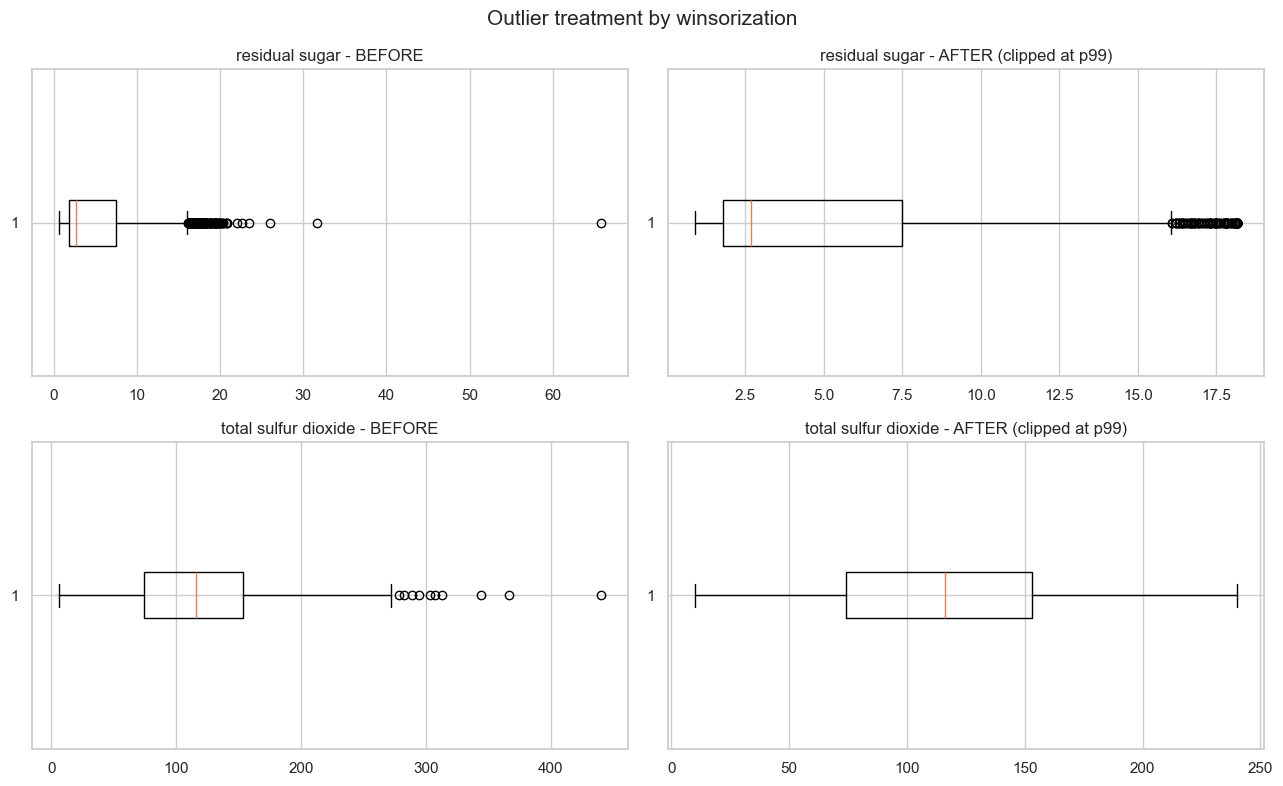

max BEFORE -> AFTER
  residual sugar: 65.8 -> 18.1
  total sulfur dioxide: 440.0 -> 240.0


In [3]:
winsorized = winsorize_outliers(cleaned)
cols = ['residual sugar', 'total sulfur dioxide']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(cols):
    axes[i, 0].boxplot(cleaned[col], vert=False)
    axes[i, 0].set_title(f'{col} - BEFORE')
    axes[i, 1].boxplot(winsorized[col], vert=False)
    axes[i, 1].set_title(f'{col} - AFTER (clipped at p99)')
plt.suptitle('Outlier treatment by winsorization', fontsize=15)
plt.tight_layout()
plt.savefig('reports/figures/prep_winsorize_before_after.png', dpi=120)
plt.show()

print('max BEFORE -> AFTER')
for col in cols:
    print(f'  {col}: {cleaned[col].max():.1f} -> {winsorized[col].max():.1f}')

## 3. Encoding wine_type

In [4]:
encoded = encode_wine_type(winsorized)
print('wine_type values after encoding (red=0, white=1):')
print(encoded['wine_type'].value_counts())

wine_type values after encoding (red=0, white=1):
wine_type
1    3961
0    1359
Name: count, dtype: int64


## 4. Scaling (before / after)

StandardScaler brings every feature to mean 0, std 1, so distance-based models
treat them fairly.

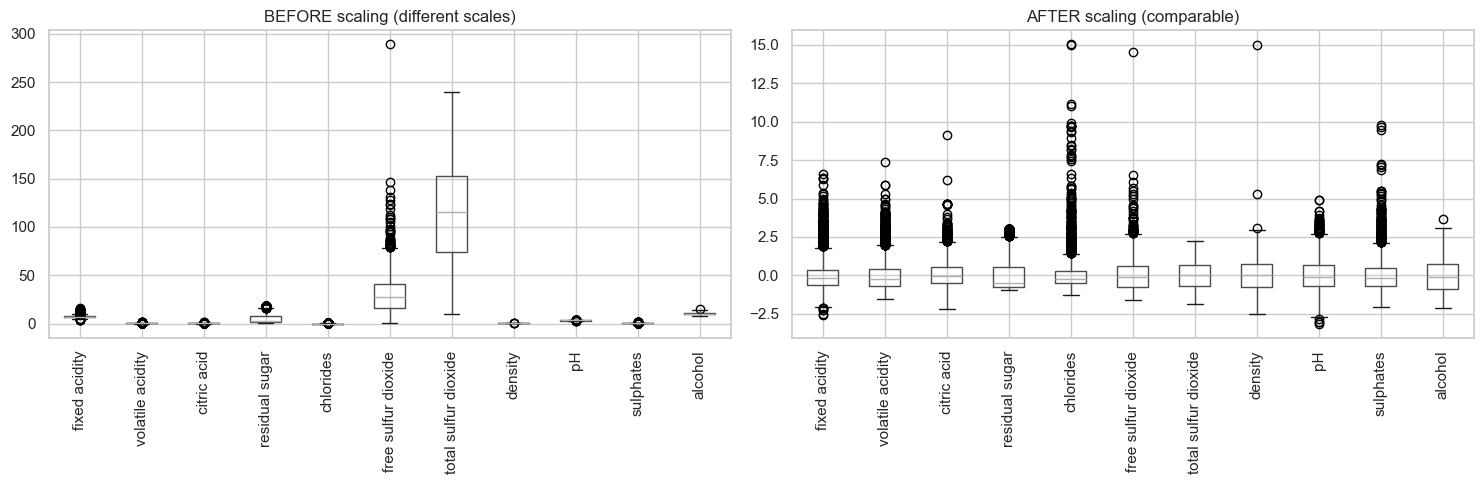

Means after scaling (should be ~0):
fixed acidity           0.0
volatile acidity       -0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates              -0.0
alcohol                 0.0


In [5]:
scaler = StandardScaler()
scaled_vals = scaler.fit_transform(encoded[FEATURE_COLUMNS])
scaled = pd.DataFrame(scaled_vals, columns=FEATURE_COLUMNS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
encoded[FEATURE_COLUMNS].boxplot(ax=axes[0], rot=90)
axes[0].set_title('BEFORE scaling (different scales)')
scaled.boxplot(ax=axes[1], rot=90)
axes[1].set_title('AFTER scaling (comparable)')
plt.tight_layout()
plt.savefig('reports/figures/prep_scaling_before_after.png', dpi=120)
plt.show()

print('Means after scaling (should be ~0):')
print(scaled.mean().round(3).to_string())

## Summary

- 6.497 -> 5.320 rows after removing duplicates (~18%).
- No missing values.
- Outliers in `residual sugar` and `total sulfur dioxide` clipped at p99.
- `wine_type` encoded 0/1.
- All 11 features standardized (mean 0, std 1).
- Result: clean, scaled dataset ready for clustering and modeling.